## Install dependencies

In [ ]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
from tqdm import tqdm
!pip install gensim
import gensim.downloader as api
from gensim.models import KeyedVectors
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec
import pprint
import seaborn as sns

##경로 설정 및 drive 연결


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
ls

본인의 경로로 셋팅해주세요

In [ ]:
cd /content/drive/MyDrive/Assistant/samsung/samsung_1

In [ ]:
ls

# Practice 1. One-hot encoding 예제

In [ ]:
# 단어 집합 (vocabulary)
vocab = ['king', 'queen', 'food', 'milk']

# One-Hot Encoding 함수
def one_hot_encode(word, vocab):
    one_hot_vector = np.zeros(len(vocab))
    index = vocab.index(word)
    one_hot_vector[index] = 1
    return one_hot_vector

# 단어들을 One-Hot Encoding으로 변환
king_vector = one_hot_encode('king', vocab)
queen_vector = one_hot_encode('queen', vocab)
food_vector = one_hot_encode('food', vocab)
milk_vector = one_hot_encode('milk', vocab)

# 벡터들 출력
print(f"'king'의 One-Hot Encoding: {king_vector}")
print(f"'queen'의 One-Hot Encoding: {queen_vector}")
print(f"'food'의 One-Hot Encoding: {food_vector}")
print(f"'milk'의 One-Hot Encoding: {milk_vector}")

##1.1 단어간 유사도 계산

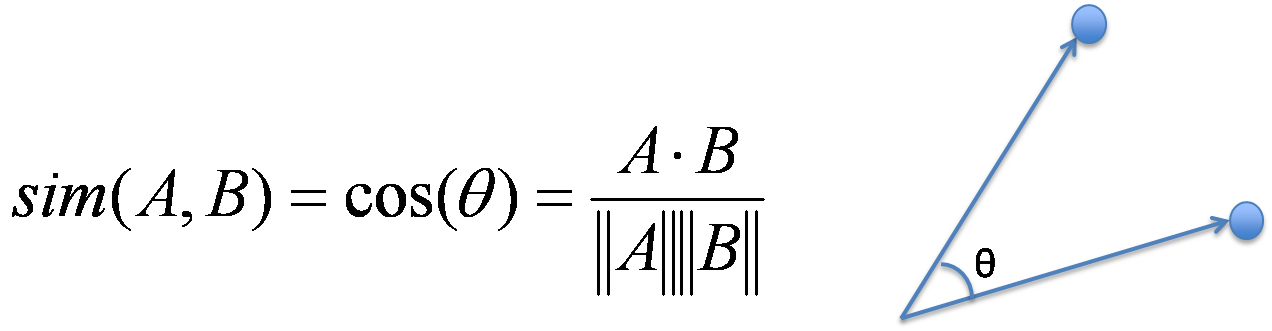

In [ ]:
# 코사인 유사도 계산
def cosine_similarity_custom(vec1, vec2):
    vec1 = np.array(vec1)
    vec2 = np.array(vec2)

    #hint 1: vector 간 dot 연산 np.dot(x1, x2)
    #hint 2: vector의 norm 구하기 np.linalg.norm(x)

    #TODO: 위의 hint를 사용해, cos_sim을 직접 계산해 보시오
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)

    if norm1 == 0 or norm2 == 0:
        return 0.0

    cos_sim = np.dot(vec1, vec2) / (norm1 * norm2)
    return cos_sim

In [ ]:
similarity_king_queen = cosine_similarity_custom(king_vector, queen_vector)
similarity_king_food = cosine_similarity_custom(king_vector, food_vector)
similarity_king_milk = cosine_similarity_custom(king_vector, milk_vector)

print(f"'king'과 'queen'의 유사도 (One-Hot): {similarity_king_queen}")
print(f"'king'과 'food'의 유사도 (One-Hot): {similarity_king_food}")
print(f"'king'과 'milk'의 유사도 (One-Hot): {similarity_king_milk}")

# 결과 시각화
cos_sim_matrix = cosine_similarity([king_vector, queen_vector, food_vector, milk_vector])

sns.heatmap(cos_sim_matrix, annot=True, xticklabels=vocab, yticklabels=vocab)
plt.title("Cosine Similarity (One-Hot Encoding)")
plt.show()

# Practice 2. Word Embedding 예제


### 2-1. Word2Vec 학습해보기

In [ ]:
sentences = [
    ['king', 'queen', 'man', 'woman'],
    ['king', 'man', 'queen', 'woman'],
    ['king', 'man'],
    ['queen', 'woman'],
    ['food', 'milk', 'bread', 'cheese'],
    ['milk', 'cheese', 'bread', 'food'],
    ['food', 'bread'],
    ['milk', 'cheese']
]

# Word2Vec 모델 학습
word2vec = Word2Vec(sentences, vector_size=50, window=2, min_count=1, sg=0)

In [ ]:
vocab = ['king', 'queen', 'food', 'milk']

corpus_embeddings = np.array([word2vec.wv[word] for word in vocab])

king_vector = corpus_embeddings[0]
queen_vector = corpus_embeddings[1]
food_vector = corpus_embeddings[2]
milk_vector = corpus_embeddings[3]

similarity_king_queen = cosine_similarity_custom(king_vector, queen_vector)
similarity_king_food = cosine_similarity_custom(king_vector, food_vector)
similarity_king_milk = cosine_similarity_custom(king_vector, milk_vector)

print(f"'king'과 'queen'의 유사도 (Word2Vec): {similarity_king_queen}")
print(f"'king'과 'food'의 유사도 (Word2Vec): {similarity_king_food}")
print(f"'king'과 'milk'의 유사도 (Word2Vec): {similarity_king_milk}")

# 코사인 유사도 결과를 시각적으로 확인
cos_sim_matrix = cosine_similarity([king_vector, queen_vector, food_vector, milk_vector])

sns.heatmap(cos_sim_matrix, annot=True, xticklabels=vocab, yticklabels=vocab)
plt.title("Cosine Similarity (Word2Vec)")
plt.show()

In [ ]:
word2vec.wv.similarity(vocab[0], vocab[1])

In [ ]:
word2vec.wv.most_similar('queen')

### 2-2. GloVe

In [ ]:
ls

In [ ]:
from gensim.models import KeyedVectors

def load_embedding_model():
    """ Load GloVe Vectors
        Return:
            wv_from_bin: All 400000 embeddings, each length 200
    """
    import gensim.downloader as api
    wv_from_bin = api.load("glove-wiki-gigaword-200")
    print("Loaded vocab size %i" % len(wv_from_bin.key_to_index.keys()))
    return wv_from_bin

glove = load_embedding_model()

In [ ]:
vocab = ['king', 'queen', 'food', 'milk']

In [ ]:
# Print the dimension of the GloVe vectors
print(f'Dimensions of the GloVe vectors: {glove.vectors.shape}')

# Sample corpus embedding from Glove
corpus_embeddings = np.array([glove[word] for word in vocab])

In [ ]:
king_vector = corpus_embeddings[0]
queen_vector = corpus_embeddings[1]
food_vector = corpus_embeddings[2]
milk_vector = corpus_embeddings[3]

similarity_king_queen = cosine_similarity_custom(king_vector, queen_vector)
similarity_king_food = cosine_similarity_custom(king_vector, food_vector)
similarity_king_milk = cosine_similarity_custom(king_vector, milk_vector)

print(f"'king'과 'queen'의 유사도 (GloVe): {similarity_king_queen}")
print(f"'king'과 'food'의 유사도 (GloVe): {similarity_king_food}")
print(f"'king'과 'milk'의 유사도 (GloVe): {similarity_king_milk}")

# 코사인 유사도 결과를 시각적으로 확인
cos_sim_matrix = cosine_similarity([king_vector, queen_vector, food_vector, milk_vector])

import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cos_sim_matrix, annot=True, xticklabels=vocab, yticklabels=vocab)
plt.title("Cosine Similarity (GloVe)")
plt.show()

In [ ]:
pprint.pprint(glove.similarity('king', 'queen'))

In [ ]:
pprint.pprint(glove.most_similar('king'))

# Practice 3. Word Embedding 추가 실습

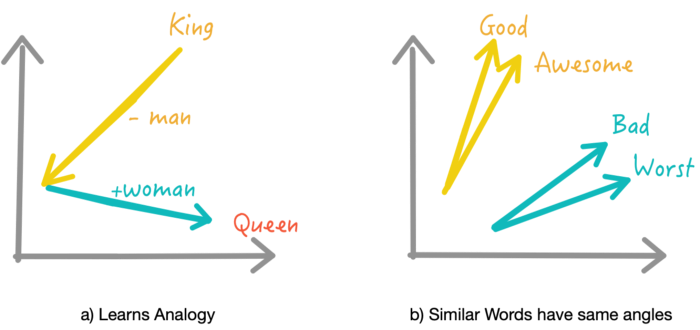

In [ ]:
# import gensim.downloader as api
# glove = api.load("glove-wiki-gigaword-200")

### 3.1. Analogy 실습

In [ ]:
def analogy(a, b, c, topn=5):
    print(f"Q: {a} - {b} + {c}?")

    result = glove.most_similar(positive=[a, c], negative=[b], topn=topn)
    for word, score in result:
        print(f"→ {word} (score: {score:.4f})")

analogy("king", "man", "woman")

In [ ]:
analogy("biggest", "big", "large")

In [ ]:
analogy("cats", "cat", "dog")

In [ ]:
analogy("ran", "run", "go")

In [ ]:
analogy("writer", "pen", "computer")

In [ ]:
analogy("asia", "korea", "france")

In [ ]:
# Try your examples!!!

analogy("a", "b", "c") # a - b + c = ?

### 3.2. 비슷한 단어의 angle test 실습

In [ ]:
vec_good = glove['good']
vec_best = glove['best']
vec_bad = glove['bad']
vec_worst = glove['worst']

# 벡터 차이
diff_a = vec_best - vec_good      # good → best
diff_b = vec_worst - vec_bad         # bad → worst

sim = cosine_similarity(diff_a.reshape(1, -1), diff_b.reshape(1, -1))
print(f"'good→best'과 'bad→worst' 관계 유사도 (GloVe): {sim[0][0]:.4f}")

In [ ]:
vec_student = glove['student']
vec_professor = glove['professor']
vec_employee = glove['employee']
vec_manager = glove['manager']

# 벡터 차이
diff_a = vec_professor - vec_student      # student → professor
diff_b = vec_manager - vec_employee         # employee → manager

sim = cosine_similarity(diff_a.reshape(1, -1), diff_b.reshape(1, -1))
print(f"'student→professor'과 'employee→manager' 관계 유사도 (GloVe): {sim[0][0]:.4f}")

In [ ]:
vec_king = glove['king']
vec_queen = glove['queen']
vec_actor = glove['actor']
vec_actress = glove['actress']

# 벡터 차이
diff_a = vec_queen - vec_king      # king → queen
diff_b = vec_actress - vec_actor         # actor → actress

sim = cosine_similarity(diff_a.reshape(1, -1), diff_b.reshape(1, -1))
print(f"'king→queen'과 'actor→actress' 관계 유사도 (GloVe): {sim[0][0]:.4f}")

In [ ]:
vec_paris = glove['paris']
vec_france = glove['france']
vec_seoul = glove['seoul']
vec_korea = glove['korea']

# 벡터 차이
diff_a = vec_france - vec_paris      # paris → france
diff_b = vec_korea - vec_seoul         # seoul → korea

sim = cosine_similarity(diff_a.reshape(1, -1), diff_b.reshape(1, -1))
print(f"'paris→france'과 'seoul→korea' 관계 유사도 (GloVe): {sim[0][0]:.4f}")

In [ ]:
# Try your examples!!!

vec_a = glove['a']
vec_b = glove['b']
vec_c = glove['c']
vec_d = glove['d']

# 벡터 차이
diff_a = vec_a - vec_b      # b → a
diff_b = vec_c - vec_d         # d → c

sim = cosine_similarity(diff_a.reshape(1, -1), diff_b.reshape(1, -1))
print(f"'b→a'과 'd→c' 관계 유사도 (GloVe): {sim[0][0]:.4f}")

# Task 1: Word Embedding

### 1.1. word embedding된 벡터를 통해 가장 관련이 적은 단어 확인해보기


In [ ]:
vocab_list = list(glove.index_to_key)

In [ ]:
# 원하는 단어가 있는지 vocab_list에 있는지 확인(소문자로 검색)
word = 'samsung'
print(word in vocab_list)

In [ ]:
print(glove.doesnt_match("breakfast cereal dinner lunch".split())) #find least similiar word

In [ ]:
print(glove.doesnt_match("samsung kaist yonsei".split()))

In [ ]:
print(glove.doesnt_match("golf baseball singing".split()))

In [ ]:
#Try anything
you = "lee kim kang james"
print(glove.doesnt_match(you.split()))

### 1.2. 4개 이상의 단어들을 입력하고 유사도가 높은 단어들끼리 매칭해보기

'korea' - 'seoul',   
'japan' - 'tokyo',  
'china' - 'beijing'

In [ ]:
def cosine_similarity_custom(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

def display_pca_scatterplot(model, words=None, sample=0):
    if words is None:
        if sample > 0:
            words = np.random.choice(list(model.vocab.keys()), sample)
        else:
            words = [word for word in model.vocab]

    # 단어 벡터 추출
    word_vectors = np.array([model[w] for w in words])

    # PCA 수행
    pca = PCA(n_components=2)
    twodim = pca.fit_transform(word_vectors)[:, :2]

    # 단어 시각화
    plt.figure(figsize=(10, 10))
    plt.scatter(twodim[:, 0], twodim[:, 1], edgecolors='k', c='r')
    for word, (x, y) in zip(words, twodim):
        plt.annotate(word, (x, y), xytext=(x + 0.05, y + 0.05))

    # 유사한 단어 쌍 연결
    for i in range(len(words)):
        similarities = []
        for j in range(len(words)):
            if i != j:
                cos_sim = cosine_similarity_custom(word_vectors[i], word_vectors[j])
                similarities.append((cos_sim, i, j))
        # 가장 유사한 단어 쌍 찾기
        most_similar = max(similarities, key=lambda item: item[0])
        _, idx1, idx2 = most_similar
        plt.plot([twodim[idx1, 0], twodim[idx2, 0]], [twodim[idx1, 1], twodim[idx2, 1]], 'k--', linewidth=0.5)

    plt.show()

In [ ]:
display_pca_scatterplot(glove,
    ['korea', 'seoul', 'japan', 'tokyo', 'china', 'beijing'])

In [ ]:
#Try yourself
display_pca_scatterplot(glove,
    ['korea', 'hyundai', 'japan', 'toyota', 'german', 'bmw'])

In [ ]:
#Try yourself
display_pca_scatterplot(glove,
    ['korea', 'hyundai', 'japan', 'toyota', 'german', 'bmw'])

## 1.3. BERT-based embedding 실습




*BERT에 대한 자세한 내용은 2일차에 학습 예정

In [ ]:
import torch
from transformers import BertTokenizer, BertModel
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased", output_hidden_states=True)
model.eval()

sent1 = "He deposited money in the bank"
sent2 = "The river overflowed near the bank"

def get_token_embedding(sentence, target_words):
    tokens = tokenizer.tokenize(sentence)
    inputs = tokenizer(sentence, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
        hidden_states = outputs.hidden_states

    last_hidden = hidden_states[-1][0]
    tokenized = tokenizer.tokenize(sentence)

    word_vectors = {}
    for target_word in target_words:
        idxs = [i for i, tok in enumerate(tokenized) if tok == target_word]
        if not idxs:
            print(f"'{target_word}' not found in: {sentence}")
            continue
        word_vectors[target_word] = last_hidden[idxs[0]].numpy()

    return word_vectors

# 각 문장에서 'bank' 및 'river' 벡터 추출
vecs1 = get_token_embedding(sent1, ["bank"])  # river는 없음
vecs2 = get_token_embedding(sent2, ["bank", "river"])
sim_bank_river = cosine_similarity([vecs1["bank"]], [vecs2["river"]])[0][0]
print(f"Cosine similarity between 'bank' and 'river' : {sim_bank_river:.4f}")
sim_bank_river = cosine_similarity([vecs2["bank"]], [vecs2["river"]])[0][0]
print(f"Cosine similarity between 'bank' and 'river' : {sim_bank_river:.4f}")

In [ ]:
sent1 = "He deposited money in the bank"
sent2 = "The river overflowed near the bank"

tokens1 = sent1.lower().split() # word 단위 토크나이징
tokens2 = sent2.lower().split()

vec_bank1 = glove['bank']
vec_bank2 = glove['bank'] # 동일한 벡터

def glove_similarities(tokens, target='bank'):
    target_vec = glove[target]
    sims = []
    for tok in tokens:
        if tok in glove:
            sim = cosine_similarity([target_vec], [glove[tok]])[0][0]
            sims.append((tok, sim))
        else:
            sims.append((tok, None))
    return sims

sims1 = glove_similarities(tokens1)
sims2 = glove_similarities(tokens2)

river_bank = sims2[1]
print(f"Cosine similarity between 'bank' and 'river' from sent2 : {river_bank}")

*Try your examples!!

In [ ]:
sent1 = "He deposited money in the bank"
sent2 = "The river overflowed near the bank"

# 각 문장에서 'bank' 및 'river' 벡터 추출
vecs1 = get_token_embedding(sent1, ["bank"])  # river는 없음
vecs2 = get_token_embedding(sent2, ["bank", "river"])
sim_bank_river = cosine_similarity([vecs1["bank"]], [vecs2["river"]])[0][0]
print(f"Cosine similarity between 'bank' and 'river' : {sim_bank_river:.4f}")
sim_bank_river = cosine_similarity([vecs2["bank"]], [vecs2["river"]])[0][0]
print(f"Cosine similarity between 'bank' and 'river' : {sim_bank_river:.4f}")

In [ ]:
sent1 = "He deposited money in the bank"
sent2 = "The river overflowed near the bank"

tokens1 = sent1.lower().split() # word 단위 토크나이징
tokens2 = sent2.lower().split()

vec_bank1 = glove['bank']
vec_bank2 = glove['bank'] # 동일한 벡터

sims1 = glove_similarities(tokens1)
sims2 = glove_similarities(tokens2)

river_bank = sims2[1]
print(f"Cosine similarity between 'bank' and 'river' from sent2 : {river_bank}")

# Task 2. Sequential Learning

## 2-1. RNN으로 텍스트 생성

### 2-1-1. One-to-one

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# 예제 데이터 (텍스트를 단어 인덱스로 변환)
text = "hello world machine learning deep learning natural language processing"
vocab = sorted(set(text.split()))
word_to_index = {w: i for i, w in enumerate(vocab)}
index_to_word = {i: w for i, w in enumerate(vocab)}
sequences = [word_to_index[w] for w in text.split()]

In [ ]:
# 데이터셋 준비
def create_dataset(seq, step=1):
    x, y = [], []
    for i in range(0, len(seq) - step):
        x.append(seq[i:i+step])
        y.append(seq[i+step])
    return np.array(x).reshape(-1, 1), np.array(y)
    # input data 수가 1이기 때문에
    # x: (N,) → (N, 1) 변환으로 RNN의 (batch_size, time_steps) 형식 맞추기

X, y = create_dataset(sequences)

In [ ]:
# 모델 구성
model = Sequential()

# input embedding / input 차원은 vocab size로, output 차원은 10, input 길이는 1
model.add(Embedding(input_dim=len(vocab), output_dim=10, input_length=1))

# RNN cell 관련 / hidden state 차원은 50
model.add(SimpleRNN(50))

# output dense layer
model.add(Dense(len(vocab), activation='softmax'))

# 학습 규칙 설정 / Adam optimizer와 classification 용 loss 계산
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

In [ ]:
# 모델 훈련
model.fit(X, y, epochs=200, verbose=0)

In [ ]:
# 텍스트 생성 함수
def generate_text(seed_text, num_words):
    result = seed_text.split()
    for _ in range(num_words):
        encoded = [word_to_index.get(w, 0) for w in result[-1:]] # 마지막 단어를 index로 사용
        encoded = pad_sequences([encoded], maxlen=1)  # 1개보다 적으면 패딩 사용
        predicted = model.predict(encoded, verbose=0)
        next_word = index_to_word[np.argmax(predicted)]
        result.append(next_word)
    return ' '.join(result)

In [ ]:
# 텍스트 생성 예제
seed_text = "hello"
# seed_text = "hello world"
# seed_text = "hello world machine"
# seed_text = "hello world machine learning"
generated_text = generate_text(seed_text, 5)
print(f"생성된 텍스트: {generated_text}")

### 2-1-2. Many-to-one

직접 One-to-one이 Many-to-one이 되도록 바꿔보자 (1 -> 1 => 3 -> 1)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# 예제 데이터 (텍스트를 단어 인덱스로 변환)
text = "hello world machine learning deep learning natural language processing"
vocab = sorted(set(text.split()))
word_to_index = {w: i for i, w in enumerate(vocab)}
index_to_word = {i: w for i, w in enumerate(vocab)}
sequences = [word_to_index[w] for w in text.split()]

In [ ]:
# 데이터셋 준비
############### CHANGE HERE ###############
def create_dataset(seq, step=3):
###########################################
    x, y = [], []
    for i in range(0, len(seq) - step):
        x.append(seq[i:i+step])
        y.append(seq[i+step])
    return np.array(x), np.array(y)

X, y = create_dataset(sequences)

In [ ]:
# 모델 구성
model = Sequential()

############### CHANGE HERE ###############
# input embedding / input 차원은 vocab size로, output 차원은 10, input 길이는 3
model.add(Embedding(input_dim=len(vocab), output_dim=10, input_length=3))
###########################################

# RNN cell 관련
model.add(SimpleRNN(50))

# output dense layer
model.add(Dense(len(vocab), activation='softmax'))

# 학습 규칙 설정 / Adam optimizer와 classification 용 loss 계산
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

In [ ]:
# 모델 훈련
model.fit(X, y, epochs=200, verbose=0)

In [ ]:
# 텍스트 생성 함수
def generate_text(seed_text, num_words):
    result = seed_text.split()
    for _ in range(num_words):
        ############### CHANGE HERE ###############
        encoded = [word_to_index.get(w, 0) for w in result[-3:]] # 마지막 3개의 단어를 index로 사용
        encoded = pad_sequences([encoded], maxlen=3)  # 3개보다 적으면 패딩 사용
        ###########################################
        predicted = model.predict(encoded, verbose=0)
        next_word = index_to_word[np.argmax(predicted)]
        result.append(next_word)
    return ' '.join(result)

In [ ]:
# 텍스트 생성 예제
seed_text = "hello"
# seed_text = "hello world"
# seed_text = "hello world machine"
# seed_text = "hello world machine learning"
generated_text = generate_text(seed_text, 5)
print(f"생성된 텍스트: {generated_text}")

In [ ]:
seed_text = "samsung"
generated_text = generate_text(seed_text, 5)
print(f"생성된 텍스트: {generated_text}")

## 2-2. LSTM으로 sentiment classification

시작하기 전, 오른쪽 상단의 펼치기 표시를 눌러 런타임 유형을 T4로 바꿔주세요. (GPU 사용 필요 실습)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.models import load_model

In [ ]:
# IMDb 데이터셋 로드
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=20000)
maxlen = 100
X_train = sequence.pad_sequences(X_train, maxlen=maxlen)
X_test = sequence.pad_sequences(X_test, maxlen=maxlen)

In [ ]:
# 모델 구성
model = Sequential()

# Input embedding
model.add(Embedding(input_dim=20000, output_dim=128, input_length=maxlen))

# LSTM cell / dropout? 입력에 대해 0.2는 무시하도록 학습 / recurrent_dropout? 과거 정보에 대해 0.2는 무시하도록 학습
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))

# Output dense layer
model.add(Dense(1, activation='sigmoid'))

# binary classification
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
import tensorflow as tf
print("GPUs :", tf.config.list_physical_devices('GPU'))

In [ ]:
# 모델 훈련
model.fit(X_train, y_train, batch_size=32, epochs=5, validation_data=(X_test, y_test))

In [ ]:
# 모델 평가
score, acc = model.evaluate(X_test, y_test, batch_size=32)
print(f'테스트 정확도: {acc}')

In [ ]:
# 새로운 리뷰에 대한 예측
def predict_sentiment(review, word_to_index, model, maxlen=100):
    # 리뷰를 정수 인덱스로 변환
    encoded_review = [word_to_index.get(word, 0) for word in review.split()]
    padded_review = sequence.pad_sequences([encoded_review], maxlen=maxlen)

    # 예측
    prediction = model.predict(padded_review)
    return prediction[0][0]

# IMDb 데이터셋의 단어 사전
word_index = imdb.get_word_index()

In [ ]:
# 테스트

new_review = "this movie wasn't excellent and fantastic. this movie wasn't excellent and fantastic. this movie wasn't excellent and fantastic."
# new_review = "FILL_YOURS"

predicted_sentiment = predict_sentiment(new_review, word_index, model, maxlen=maxlen)
print(f'리뷰: "{new_review}"')
print(f'예측된 감정 (0 = 부정적, 1 = 긍정적): {predicted_sentiment}')
if predicted_sentiment > 0.5 :
  result = '긍정'
else:
  result= '부정'
print(result)

# Task 3: Sequential Learning

### 3.1. 번역기 만들기(영-프)

#### 3.1.1. LSTM

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Embedding, RepeatVector
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [ ]:
# 데이터셋
english_sentences = [
    'he is a good boy',
    'she is a beautiful girl',
    'they are playing outside',
    'we are learning LSTM',
    'what is your name',
    'where is the library',
    'when will you come',
    'why are you crying',
    'how are you today',
    'i am fine thank you'
]
english_sentences = ['<SOS> ' + sent + ' <EOS>' for sent in english_sentences]


french_sentences = [
    'il est un bon garçon',
    'elle est une belle fille',
    'ils jouent dehors',
    'nous apprenons LSTM',
    'quel est ton nom',
    'où est la bibliothèque',
    'quand viendrez-vous',
    'pourquoi pleures-tu',
    'comment allez-vous aujourd\'hui',
    'je vais bien merci'
]

french_sentences = ['<SOS> ' + sent + ' <EOS>' for sent in french_sentences]

In [ ]:
#Word-level Tokenizing
lstm_eng_tokenizer = Tokenizer()
lstm_eng_tokenizer.fit_on_texts(english_sentences)
lstm_eng_vocab_size = len(lstm_eng_tokenizer.word_index) + 1
lstm_eng_sequences = lstm_eng_tokenizer.texts_to_sequences(english_sentences)

lstm_fra_tokenizer = Tokenizer()
lstm_fra_tokenizer.fit_on_texts(french_sentences)
lstm_fra_vocab_size = len(lstm_fra_tokenizer.word_index) + 1
lstm_fra_sequences = lstm_fra_tokenizer.texts_to_sequences(french_sentences)

lstm_max_length_eng = max(len(seq) for seq in lstm_eng_sequences)
lstm_max_length_fra = max(len(seq) for seq in lstm_fra_sequences)

# Padding sequences
lstm_eng_sequences = pad_sequences(lstm_eng_sequences, maxlen=lstm_max_length_eng, padding='post')
lstm_fra_sequences = pad_sequences(lstm_fra_sequences, maxlen=lstm_max_length_fra, padding='post')

lstm_fra_input = lstm_fra_sequences[:, :-1]
lstm_fra_output = to_categorical(lstm_fra_sequences[:, 1:], num_classes=lstm_fra_vocab_size)


# LSTM 모델 정의
lstm_model = Sequential()
lstm_model.add(Embedding(lstm_eng_vocab_size, 256, input_length=lstm_max_length_eng, mask_zero=True))
lstm_model.add(LSTM(256))
lstm_model.add(RepeatVector(lstm_max_length_fra - 1)) # encoder hidden state 계속 넣어주기
lstm_model.add(LSTM(256, return_sequences=True))

# 출력층: 각 시점마다 프랑스어 단어 분포를 예측합니다.
lstm_model.add(Dense(lstm_fra_vocab_size, activation='softmax'))

# 모델 컴파일
lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 모델 학습
lstm_model.fit(lstm_eng_sequences, lstm_fra_output, epochs=100)

# 예측 함수
def LSTM_translate(sentence):
    lstm_seq = lstm_eng_tokenizer.texts_to_sequences([sentence])
    lstm_seq = pad_sequences(lstm_seq, maxlen=lstm_max_length_eng, padding='post')
    lstm_prediction = lstm_model.predict(lstm_seq)
    lstm_prediction = np.argmax(lstm_prediction, axis=-1)
    lstm_predicted_sentence = ' '.join([lstm_fra_tokenizer.index_word[idx] for idx in lstm_prediction[0] if idx > 0])
    return lstm_predicted_sentence

#### 3.1.2. RNN

In [ ]:
# 토큰화 및 패딩
rnn_eng_tokenizer = Tokenizer()
rnn_eng_tokenizer.fit_on_texts(english_sentences)
rnn_eng_vocab_size = len(rnn_eng_tokenizer.word_index) + 1
rnn_eng_sequences = rnn_eng_tokenizer.texts_to_sequences(english_sentences)
rnn_max_length_eng = max(len(seq) for seq in rnn_eng_sequences)
rnn_eng_sequences = pad_sequences(rnn_eng_sequences, maxlen=rnn_max_length_eng, padding='post')

rnn_fra_tokenizer = Tokenizer()
rnn_fra_tokenizer.fit_on_texts(french_sentences)
rnn_fra_vocab_size = len(rnn_fra_tokenizer.word_index) + 1
rnn_fra_sequences = rnn_fra_tokenizer.texts_to_sequences(french_sentences)
rnn_max_length_fra = max(len(seq) for seq in rnn_fra_sequences)
rnn_fra_sequences = pad_sequences(rnn_fra_sequences, maxlen=rnn_max_length_fra, padding='post')

# 입력과 출력 시퀀스의 길이를 맞추기 위해 수정
rnn_eng_input = rnn_eng_sequences[:, :-1]
rnn_fra_input = rnn_fra_sequences[:, :-1]
rnn_fra_output = to_categorical(rnn_fra_sequences[:, 1:], num_classes=rnn_fra_vocab_size)

# 모델 구성
rnn_model = Sequential()

rnn_model.add(Embedding(rnn_eng_vocab_size, 256, input_length=rnn_max_length_eng-1))

#TODO: RNN encoder 완성 / 2.1.1.과 형식 동일!
############### CHANGE HERE ###############

#1. enc-dec: rnn_model.add(SimpleRNN(num))함수를 활용하세요. num=256으로 합니다.
rnn_model.add(SimpleRNN(256, return_sequences=True))

#2. output: 출력층: 각 시점마다 프랑스어 단어 분포를 예측합니다. -> rnn_model.add(Dense(v, activation = 'softmax'))에서 v는 어떤 값을 의미할지 생각하며 완성합니다.
rnn_model.add(Dense(rnn_fra_vocab_size, activation='softmax'))


###########################################

# 모델 컴파일
rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 모델 학습
rnn_model.fit(rnn_eng_input, rnn_fra_output, epochs=100)

# 예측 함수
def RNN_translate(sentence):
    #TODO: translate 채워넣기 / 2.1.1.과 형식 동일!
    ############### CHANGE HERE ###############
    #1. 주어진 영어 문장을 정수 시퀀스로 변환합니다.
    rnn_seq = rnn_eng_tokenizer.texts_to_sequences([sentence])

    #2. 시퀀스 길이를 모델 입력에 맞게 고정합니다. - Padding사용
    rnn_seq = pad_sequences(rnn_seq, maxlen=rnn_max_length_eng-1, padding='post')

    ###########################################

    #3. 예측
    rnn_prediction = rnn_model.predict(rnn_seq)
    rnn_prediction = np.argmax(rnn_prediction, axis=-1)

    #4. 인덱스를 프랑스어 단어로 복원
    rnn_predicted_sentence = ' '.join([rnn_fra_tokenizer.index_word[idx] for idx in rnn_prediction[0] if idx > 0])

    return rnn_predicted_sentence

#### 3.1.3. 결과 비교

In [ ]:
# LSTM
# 예제 문장 번역
test_sentence = "he is a good boy"  # 정답: il est un bon garçon
translated_sentence = LSTM_translate(test_sentence)
print(f'Input: {test_sentence}')
print(f'Translated: {translated_sentence}')

In [ ]:
# RNN
# 예제 문장 번역
test_sentence = "you are a good boy"
translated_sentence = RNN_translate(test_sentence)
print(f'Input: {test_sentence}')
print(f'Translated: {translated_sentence}')

# Practice 4. Seq2Seq으로 한국어 번역기 실행


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from collections import defaultdict

In [ ]:
data = [
    ("hello", "안녕"),
    ("how are you", "잘 지내?"),
    ("what is your name", "이름이 뭐야?"),
    ("i am a student", "나는 학생이야"),
    ("where is the bus stop", "버스 정류장이 어디야?"),
    ("i like music", "나는 음악을 좋아해"),
    ("i want to go home", "집에 가고 싶어"),
    ("can you help me", "도와줄 수 있어?"),
    ("thank you very much", "정말 고마워"),
    ("see you tomorrow", "내일 봐"),

    ("this is my book", "이건 내 책이야"),
    ("that is your car", "저건 네 차야"),
    ("the weather is nice", "날씨가 좋아"),
    ("it is raining", "비가 와"),
    ("i'm hungry", "배고파"),
    ("are you okay", "괜찮아?"),
    ("i'm fine", "괜찮아"),
    ("let's eat", "밥 먹자"),
    ("come here", "이리 와"),
    ("go to sleep", "자러 가"),

    ("open the door", "문 열어"),
    ("close the window", "창문 닫아"),
    ("don't be late", "늦지 마"),
    ("study hard", "공부 열심히 해"),
    ("call me later", "나중에 전화해"),
    ("i will be back", "금방 올게"),
    ("you are my friend", "넌 내 친구야"),
    ("i miss you", "보고 싶어"),
    ("what time is it", "몇 시야?"),
    ("do you like coffee", "커피 좋아해?"),

    ("i am tired", "피곤해"),
    ("he is my brother", "그는 내 남동생이야"),
    ("she is a teacher", "그녀는 선생님이야"),
    ("they are students", "그들은 학생이야"),
    ("we are ready", "우리는 준비됐어"),
    ("it's too hot", "너무 더워"),
    ("it's cold today", "오늘은 추워"),
    ("i don't know", "모르겠어"),
    ("i understand", "이해했어"),
    ("please wait", "잠깐만 기다려"),

    ("i’m sorry", "미안해"),
    ("i forgive you", "용서할게"),
    ("turn left", "왼쪽으로 가"),
    ("turn right", "오른쪽으로 가"),
    ("go straight", "직진해"),
    ("stop here", "여기서 멈춰"),
    ("be quiet", "조용히 해"),
    ("watch out", "조심해"),
    ("what happened", "무슨 일이야?"),
    ("see you again", "또 봐"),
]

# char-level 토크나이저
# build_vocab(["hi", "hello"])
# 결과 (예시): {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3, 'h': 4, 'i': 5, 'e': 6, 'l': 7, 'o': 8}
def build_vocab(sentences):
    vocab = {"<PAD>":0, "<SOS>":1, "<EOS>":2, "<UNK>":3}
    idx = 4
    for s in sentences:
        for ch in s:
            if ch not in vocab:
                vocab[ch] = idx
                idx += 1
    return vocab

src_vocab = build_vocab([en for en, _ in data])
tgt_vocab = build_vocab([ko for _, ko in data])
inv_tgt_vocab = {v:k for k,v in tgt_vocab.items()}

## encoding과정
# 예시 : "hi"
# -> ['<SOS>', 'h', 'i', '<EOS>', '<PAD>', '<PAD>']
def encode(sentence, vocab, max_len, sos=False, eos=False):
    tokens = [vocab.get(ch, vocab["<UNK>"]) for ch in sentence]
    if sos: tokens = [vocab["<SOS>"]] + tokens
    if eos: tokens = tokens + [vocab["<EOS>"]]
    tokens = tokens[:max_len] + [vocab["<PAD>"]] * (max_len - len(tokens))
    return tokens

MAX_LEN = 10

In [ ]:
class Seq2SeqDataset(Dataset):
    def __init__(self, data):
        self.pairs = data

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_ids = encode(src, src_vocab, MAX_LEN)
        tgt_ids_in = encode(tgt, tgt_vocab, MAX_LEN, sos=True)
        tgt_ids_out = encode(tgt, tgt_vocab, MAX_LEN, eos=True)
        return torch.tensor(src_ids), torch.tensor(tgt_ids_in), torch.tensor(tgt_ids_out)

dataset = Seq2SeqDataset(data)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

# -----------------------------
# 모델 정의 (Encoder & Decoder)
# -----------------------------
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_size, batch_first=True)

    def forward(self, x):
        x = self.embed(x)
        outputs, (h, c) = self.lstm(x)
        return h, c

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h, c):
        x = self.embed(x)
        outputs, (h, c) = self.lstm(x, (h, c))
        logits = self.fc(outputs)
        return logits, h, c

# -----------------------------
# 학습
# -----------------------------
encoder = Encoder(len(src_vocab), 32, 64)
decoder = Decoder(len(tgt_vocab), 32, 64)
criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab["<PAD>"])
optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=0.01)

In [ ]:
for epoch in range(100):
    total_loss = 0
    for src, tgt_in, tgt_out in loader:
        h, c = encoder(src)
        logits, _, _ = decoder(tgt_in, h, c)
        loss = criterion(logits.view(-1, logits.size(-1)), tgt_out.view(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss:.4f}")


In [ ]:
def translate(src_text):
    src_ids = encode(src_text, src_vocab, MAX_LEN)
    src_tensor = torch.tensor([src_ids])
    h, c = encoder(src_tensor)

    tgt_input = torch.tensor([[tgt_vocab["<SOS>"]]])
    output = []

    for _ in range(MAX_LEN):
        logits, h, c = decoder(tgt_input, h, c)
        pred = logits.argmax(-1)[:,-1].item()
        if pred == tgt_vocab["<EOS>"]:
            break
        output.append(inv_tgt_vocab.get(pred, "?"))
        tgt_input = torch.tensor([[pred]])

    return "".join(output)

# -----------------------------
# 테스트
# -----------------------------
test_sentences = [
    "hello",
    "i am tired",
    "go to sleep",
    "where is the bus stop",
    "do you like coffee",
    "turn left",
    "i miss you"
]

for s in test_sentences:
    print(f"EN: {s} → KO: {translate(s)}")

# Task 4: Attention

## 4.1. Summarization task

In [ ]:
ls

In [ ]:
import json
import pandas as pd

raw_data = pd.read_csv("Reviews.csv", nrows = 250)
print('전체 리뷰 개수 :',(len(raw_data)))
raw_data = raw_data[['Text','Summary']]
raw_data = raw_data.rename(columns={'Text': 'paragraph', 'Summary': 'summary'})

raw_data = raw_data.to_dict(orient='records')

raw_data = [
    {"paragraph": item["paragraph"], "summary": item["summary"]}
    for item in raw_data
    if isinstance(item["paragraph"], str) and isinstance(item["summary"], str)
]

In [ ]:
from torch.utils.data import Dataset
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from collections import defaultdict

data = [(item["paragraph"], item["summary"]) for item in raw_data]
# simple whitespace tokenizer
import re
def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

# build vocab
from collections import defaultdict
def build_vocab(dataset, min_freq=2):
    freq = defaultdict(int)
    for src, tgt in dataset:
        for tok in tokenize(src) + tokenize(tgt):
            freq[tok] += 1
    vocab = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
    idx = 4
    for tok, count in freq.items():
        if count >= min_freq:
            vocab[tok] = idx
            idx += 1
    return vocab

vocab = build_vocab(data)
inv_vocab = {v: k for k, v in vocab.items()}

def encode(text, vocab, max_len, add_sos=False, add_eos=False):
    tokens = tokenize(text)
    ids = [vocab.get(tok, vocab["<UNK>"]) for tok in tokens]
    if add_sos: ids = [vocab["<SOS>"]] + ids
    if add_eos: ids = ids + [vocab["<EOS>"]]
    ids = ids[:max_len] + [vocab["<PAD>"]] * (max_len - len(ids))
    return ids

MAX_SRC_LEN = 50
MAX_TGT_LEN = 15

class SummDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        src, tgt = self.data[idx]
        src_ids = encode(src, vocab, MAX_SRC_LEN)
        tgt_in = encode(tgt, vocab, MAX_TGT_LEN, add_sos=True)
        tgt_out = encode(tgt, vocab, MAX_TGT_LEN, add_eos=True)
        return torch.tensor(src_ids), torch.tensor(tgt_in), torch.tensor(tgt_out)

dataset = SummDataset(data)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

In [ ]:
from tqdm import tqdm
import torch.optim as optim

# Encoder
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        x = self.embed(x)
        outputs, (h, c) = self.lstm(x)
        return outputs, (h, c)

# Luong Attention (dot-product 기반)
class LuongAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, decoder_hidden, encoder_outputs):
        # Step1: decoder_hidden을 (B, H, 1)로 변환
        hidden = decoder_hidden.permute(1, 2, 0)

        # Step2: batch-wise dot product
        # hint: 어떤 값들의 dot product를 수행해야 할까?
        score = torch.bmm(encoder_outputs, hidden).squeeze(-1)  # → (B, T)

        # Step3: get attention weights
        # hint: attention weights를 구하려면 어떤 값을 softmax 해야 할까?
        attn_weights = torch.softmax(score, dim=1)  # (B, T)

        # Step 4: attention weights을 encoder_outputs에 곱해서 context vector 계산
        # hint: context vector를 계산하려면 attention weight와 어떤 값들의 곱의 sum이 필요할까?
        context = torch.sum(
             encoder_outputs * attn_weights.unsqueeze(-1), dim=1
        )

        return context, attn_weights

# Decoder
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.attn = LuongAttention()
        self.lstm = nn.LSTM(embed_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h, c, encoder_outputs):
        # Step1: embed x
        x = self.embed(x)  # (B, 1, E)

        # Step2: attention 계산
        # hint: enc-dec의 각각의 state를 넣어줘야 함
        context, attn_weights = self.attn(h, encoder_outputs)  # (B, H), (B, T, 1)
        context = context.unsqueeze(1)  # (B, 1, H)

        # Step3: 출력 위해, context와 input concatenate 계산
        # hint: context와 input concatenate 계산
        x = torch.cat([x, context], dim=-1)  # (B, 1, E+H)

        # Step4: 새로운 output 계산 및, 다음 hidden state 계산
        output, (h, c) = self.lstm(x, (h, c))
        logits = self.fc(output)  # (B, 1, V)
        return logits, h, c


# -----------------------------
# Training
# -----------------------------
vocab_size = len(vocab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder = Encoder(vocab_size, 32, 64).to(device)
decoder = Decoder(vocab_size, 32, 64).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=vocab["<PAD>"])
optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=0.005)


for epoch in range(30):
    total_loss = 0
    loader_tqdm = tqdm(loader, desc=f"Epoch {epoch}", leave=False)

    for src, tgt_in, tgt_out in loader_tqdm:
        src = src.to(device)
        tgt_in = tgt_in.to(device)
        tgt_out = tgt_out.to(device)
        enc_outs, (h, c) = encoder(src)
        outputs = []
        dec_input = tgt_in[:, 0].unsqueeze(1)

        for t in range(1, tgt_in.size(1)):
            logit, h, c = decoder(dec_input, h, c, enc_outs)
            outputs.append(logit)
            dec_input = tgt_in[:, t].unsqueeze(1)  # teacher forcing

        logits = torch.cat(outputs, dim=1)
        loss = criterion(logits.view(-1, vocab_size), tgt_out[:, 1:].reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loader_tqdm.set_postfix(loss=loss.item())

    print(f"Epoch {epoch}, Total Loss: {total_loss:.4f}")

In [ ]:
import torch

# 테스트 문장
paragraph = " Robitussin I believe I have found it. I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda. The flavor is very medicinal."

def encode(text, vocab, max_len):
    tokens = text.lower().split()
    ids = [vocab.get(tok, vocab["<UNK>"]) for tok in tokens]
    ids = ids[:max_len]
    ids += [vocab["<PAD>"]] * (max_len - len(ids))
    return ids

def decode(ids, vocab):
    idx2word = {v: k for k, v in vocab.items()}
    return [idx2word[i] for i in ids if i not in {vocab["<PAD>"], vocab["<EOS>"]}]

def inference(encoder, decoder, input_seq, vocab, max_len=50, device='cpu'):
    encoder.eval()
    decoder.eval()
    idx2word = {v: k for k, v in vocab.items()}

    input_tensor = torch.tensor(input_seq).unsqueeze(0).to(device)
    enc_outputs, (h, c) = encoder(input_tensor)

    sos_token = vocab["<SOS>"]
    eos_token = vocab["<EOS>"]
    dec_input = torch.tensor([[sos_token]], device=device)

    decoded_tokens = []
    for _ in range(max_len):
        logit, h, c = decoder(dec_input, h, c, enc_outputs)
        pred_token = logit.argmax(dim=-1)[:, 0]  # (B,) shape
        token_id = pred_token.item()
        if token_id == eos_token:
            break
        decoded_tokens.append(token_id)
        dec_input = pred_token.unsqueeze(1).to(device)  # ensure on same device

    decoded_words = [idx2word[idx] for idx in decoded_tokens]
    return decoded_words

MAX_SRC_LEN = 40  # 입력 문장 길이 제한

input_ids = encode(paragraph, vocab, MAX_SRC_LEN)
summary_tokens = inference(encoder, decoder, input_ids, vocab, device=device)
print("Input:", paragraph)
print("Generated Summary:", " ".join(summary_tokens))

# Task 5: RNN 이용 image captioning 수행하기

In [ ]:
cd /content/drive/MyDrive/Assistant/samsung/samsung_1

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout
from tensorflow.keras.utils import to_categorical
from PIL import Image
import matplotlib.pyplot as plt
import pickle

# 이미지 캡션 txt
caption_file = "Flickr8k.token.txt"
# 이미지 특징 로딩 (pre-defined pkl 파일 사용)
with open("image_features.pkl", "rb") as f:
    current_image_features = pickle.load(f)


In [ ]:
def normalize_filename(name):
    return name.strip().lower()

df = pd.read_csv(caption_file, delimiter='\t', names=['image_raw', 'caption'])
df['image'] = df['image_raw'].apply(lambda x: normalize_filename(x.split('#')[0]))

N = 700
selected_images = df['image'].drop_duplicates().sample(n=N, random_state=42)
filtered_df = df[df['image'].isin(selected_images) & df['image'].isin(current_image_features.keys())].reset_index(drop=True)

In [ ]:
base_model = VGG16(weights='imagenet') #이미지 encoder용
feature_extractor = Model(inputs=base_model.input,
                          outputs=base_model.get_layer('fc2').output)

# 이미지 특징 벡터 추출 함수
def extract_features(image_path):
    image = Image.open(image_path).resize((224, 224))
    image = np.array(image)
    image = preprocess_input(image)
    image = np.expand_dims(image, axis=0)
    features = feature_extractor.predict(image)
    return features.flatten()

In [ ]:
# LSTM 모델 설계
# TODO
#####################################
# [이미지 (4096D)]         [입력 문장 (토큰 시퀀스)]
#         │                          │
#   Dense(n)                Embedding(128) → LSTM → LSTM (최종 시점만)
#         │                          │
#         └────────────── add ───────┘
#                        │
#            Dense(vocab_size, softmax)
#                        ↓
#                 다음 단어 확률 분포

# Tokenizer를 사용 -> 임베딩 차원과 캡션 시퀀스 최대 길이 설정
tokenizer = Tokenizer()

# hint: tokenizer를 text에 맞추기. df 중 어느 것?
tokenizer.fit_on_texts(df['caption'])

word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

# hint: 그림에서 embedding 차원은 몇인가?
embedding_dim = 128
max_length = 30

# 이미지 part는 제공됩니다.
input_img = Input(shape=(4096,))
image_features = Dense(128, activation='relu')(input_img)

# text part -> 단어 인덱스를 임베딩 벡터로 변환 및 LSTM으로 인코딩
input_text = Input(shape=(max_length,))

# hint: Embedding(입력_단어수, 출력_벡터크기)(입력_데이터)
# hint: vocab_size개의 단어를 embedding_dim 크기로 바꾸기
text_embedding = Embedding(vocab_size, 128)(input_text)

# hint: LSTM(출력_크기)(입력_데이터)
# hint: image_features와 더해질 수 있도록 같은 크기여야 함
lstm = LSTM(128)(text_embedding)

# decoder
decoder = tf.keras.layers.add([image_features, lstm])

# Dense(출력_단어수, activation='확률로_변환')(입력)
# vocab_size개 단어 중 하나를 고르는 확률을 만들어야 함
decoder = Dense(vocab_size, activation='softmax')(decoder)

#####################################

model = Model(inputs=[input_img, input_text], outputs=decoder)
model.compile(loss='categorical_crossentropy', optimizer='adam')
model.summary()

In [ ]:
sequences = []
for img_name, caption in zip(filtered_df['image'], filtered_df['caption']):
    tokens = caption.split()
    for i in range(1, len(tokens)):
        input_seq = tokens[:i]
        output_word = tokens[i]

        input_seq = tokenizer.texts_to_sequences([' '.join(input_seq)])[0]
        output_seq = tokenizer.texts_to_sequences([output_word])[0]

        if len(input_seq) == 0 or len(output_seq) == 0:
            continue

        input_seq = pad_sequences([input_seq], maxlen=max_length)[0]
        output_word_id = output_seq[0]

        sequences.append((img_name, input_seq, output_word_id))

X_images, X_texts, y_labels = [], [], []
for img_name, seq, word in sequences:
    if img_name in current_image_features:

        X_images.append(current_image_features[img_name])
        X_texts.append(seq)
        y_labels.append(to_categorical(word, num_classes=vocab_size))

X_images = np.array(X_images)
X_texts = np.array(X_texts)
y_labels = np.array(y_labels)

In [ ]:
#training
model.fit([X_images, X_texts], y_labels, epochs=5, batch_size=64, verbose=1)

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

def generate_caption(image_path, model, tokenizer, max_length, gen_max_len):
    feature = extract_features(image_path)
    caption = "startseq"
    print(gen_max_len)
    for _ in range(gen_max_len):
        sequence = tokenizer.texts_to_sequences([caption])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)

        y_pred = model.predict([feature.reshape(1, -1), sequence], verbose=0)
        predicted_id = np.argmax(y_pred)
        predicted_word = tokenizer.index_word.get(predicted_id, None)

        if predicted_word is None:
            break

        caption += ' ' + predicted_word
        if predicted_word == 'endseq':
            break

    return caption.replace("startseq", "").replace("endseq", "").strip()

# 이미지 경로 -> try with yours!
image_path = "images/basketball.jpg"
gen_max_len = 5
# 캡션 생성

predicted_caption = generate_caption(image_path, model, tokenizer, 30, gen_max_len)
print("Generated Caption:", predicted_caption)

# 이미지 표시
img = Image.open(image_path)

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')
plt.title(predicted_caption, fontsize=14)
plt.show()
